# CSE 256: NLP UCSD PA3 PART B :
<font color="red"> Make sure to also complete PART A of this PA (the decoding part) in a separate notebook, available in the same directory where you found this notebook. </font>


If Colab is slow, download the notebook to your local machine.
Then when done, upload it to Colab to get a link.


## Retrieval-Augmented Generation (RAG) using LangChain (40 points)

The goal of this assignment is to gain hands-on experience with aspects of **Retrieval-Augmented Generation (RAG)**, with a primary focus on the retrieval. You will use **LangChain**, a framework that simplifies integrating external knowledge into generation tasks by:

- Implementing various vector databases for efficient neural retrieval. You will use a vector database for storing our memories.
- Allowing seamless integration of pretrained text encoders, which you will access via HuggingFace models. You will use a text encoder to get text embeddings for storing in the vector database.

**Data**  
You will build a retrieval system using the [QMSum Dataset](https://github.com/Yale-LILY/QMSum), a human-annotated benchmark designed for question answering on long meeting transcripts. The dataset includes over 230 meetings across multiple domains.

### <font color='blue'>  Out: February 23 || Due: Thurday 12 March, 2026 </font>


---

**IMPORTANT:** After copying this notebook to your Google Drive along with the two data files, paste a link to your copy below. To create a publicly accessible link:
1. Click the *Share* button in the top-right corner.
2. Select "Get shareable link" and copy the link.

#### <font color="red">Link: paste your link here: </font>


---
**Notes:**

Make sure to save the notebook as you go along.

Submission instructions are located at the bottom of the notebook.

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'assignments/PA3/'
FOLDERNAME = None
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This is later used to use the IMDB reviews
%cd /content/drive/My\ Drive/$FOLDERNAME/

Mounted at /content/drive
/content/drive/My Drive/2026NLP_WINTER/PA3_CSE156_WI26


# RAG Workflow

Retrieval-Augmented Generation (RAG) systems involve several interconnected components. Below is a RAG workflow diagram from Hugging Face. Areas highlighted in blue indicate opportunities for system improvement.

In this assignment,  we will focus  on the ***Retriever**  so the PA does not cover any processes starting from "2. Reader" and below.


<img src="https://huggingface.co/datasets/huggingface/cookbook-images/resolve/main/RAG_workflow.png" height="700">










# First,  install the required model dependancies.

 <font color='orange'>Note: Colab may throw dependency warnings or import errors for some system packages (requests, opentelemetry, etc.). These can generally be ignored; your LangChain, embeddings, and FAISS code should still run fine.</font>

In [1]:
pip install -U "pydantic>=2.7,<2.12.4" "tenacity>=9.0.0,<10.0.0" "langchain>=0.3.27" "langchain-community>=0.3.31" "langchain-core>=0.3.83" langchain_chroma langchain_huggingface torch transformers matplotlib bitsandbytes sentence-transformers pacmap tqdm dataclasses-json>=0.6.7 gradio

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-exporter-otlp-proto-common==1.38.0, but you have opentelemetry-exporter-otlp-proto-common 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-proto==1.38.0, but you have opentelemetry-proto 1.40.0 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.38.0 requires opentelemetry-sdk~=1.38.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have opentelemetry-sdk 1.40.0 which is incompatible.
google-adk 1.26.0 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.40.0

In [2]:
from tqdm.notebook import tqdm
import pandas as pd
import os
import csv
import sys
import numpy as np
import time
import random
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
import textwrap
import torch


seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Disable  huffingface tokenizers parallelism
os.environ["TOKENIZERS_PARALLELISM"] = "false"


# Load the meetings dataset

In [3]:
from langchain_core.documents import Document
import csv
import sys

def load_documents(doc_file):
    max_size = sys.maxsize
    csv.field_size_limit(max_size)

    documents = {}
    with open(doc_file, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter='\t')
        for row in reader:
            if len(row) == 0:
                continue
            doc_id, content = row
            documents[doc_id] = content
    return documents


docs = []
doc_file = './meetings.tsv'
documents = load_documents(doc_file)

for doc_id in documents:
    doc = Document(
        page_content=documents[doc_id],
        metadata={'source': doc_id}
    )
    docs.append(doc)

print(f"Total meetings (docs): {len(documents)}")

Total meetings (docs): 230


# Retriever - Building the retriever 🗂️

The **retriever functions like a search engine**: given a user query, it returns relevant documents from the knowledge base.

These documents are then used by the Reader model to generate an answer. In this assignment, however, we are only focusing on the retriever, not the Reader model.

**Our goal:** Given a user question, find the most relevant documents from the knowledge base.

Key parameters:
- `top_k`: The number of documents to retrieve. Increasing `top_k` can improve the chances of retrieving relevant content.
- `chunk size`: The length of each document. While this can vary, avoid overly long documents, as too many tokens can overwhelm most reader models.


Langchain __offers a huge variety of options for vector databases and allows us to keep document metadata throughout the processing__.

 ### 1. Specify an Embedding Model and Visualize Document Lengths


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

100%|██████████| 230/230 [00:07<00:00, 30.10it/s]


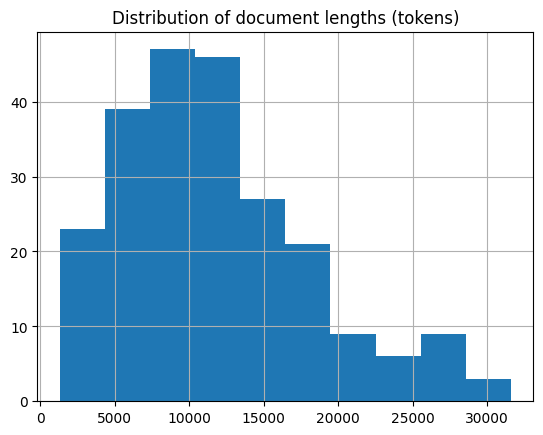

In [4]:
from transformers import AutoTokenizer
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

EMBEDDING_MODEL_NAME = "thenlper/gte-small"

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

lengths = [
    len(tokenizer(doc.page_content)["input_ids"])
    for doc in tqdm(docs)
]

pd.Series(lengths).hist()
plt.title("Distribution of document lengths (tokens)")
plt.show()

### 2. Split the Documents into Chunks

The documents (meeting transcripts) are very long—some up to 30,000 tokens! To make retrieval effective, we’ll **split each document into smaller, semantically meaningful chunks**. These chunks will serve as the snippets the retriever compares to the query, returning the `top_k` most relevant ones.

**Objective**: Create Semantically Relevant Snippets

Chunks should be long enough to capture complete ideas but not so lengthy that they lose focus.

We will use Langchain's implementation of recursive chunking with `RecursiveCharacterTextSplitter`.
- Parameter `chunk_size` controls the length of individual chunks: this length is counted by default as the number of characters in the chunk.
- Parameter `chunk_overlap` lets adjacent chunks get a bit of overlap on each other. This reduces the probability that an idea could be cut in half by the split between two adjacent chunks.

From the produced plot below, you can see that now the chunk length distribution looks better!

Total 18070 snippets to be stored in our vector store.


100%|██████████| 18070/18070 [00:21<00:00, 821.77it/s] 


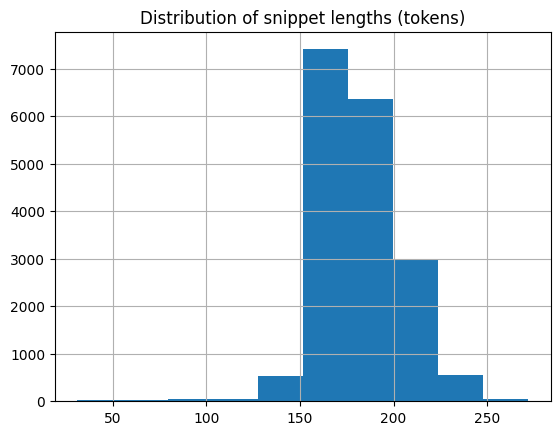

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=768,
    chunk_overlap=128,
)

doc_snippets = text_splitter.split_documents(docs)
print(f"Total {len(doc_snippets)} snippets to be stored in our vector store.")

lengths = [
    len(tokenizer(doc.page_content)["input_ids"])
    for doc in tqdm(doc_snippets)

]

pd.Series(lengths).hist()
plt.title("Distribution of snippet lengths (tokens)")
plt.show()

### 3. Build the Vector Database

To enable retrieval, we need to compute embeddings for all chunks in our knowledge base. These embeddings will then be stored in a vector database.

#### How Retrieval Works

A query is embedded using an embedding model and a similarity search finds the closest matching chunks in the vector database.

The following cell builds the vector database consisting of  all chunks in our knowledge base.


In [6]:
pip install faiss-cpu

In [7]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
import time
import sentence_transformers

# Optional device selection
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL_NAME,
    model_kwargs={"device": device},
    encode_kwargs={"normalize_embeddings": True},  # cosine similarity
)

start_time = time.time()

KNOWLEDGE_VECTOR_DATABASE = FAISS.from_documents(
    doc_snippets,
    embedding_model
)

end_time = time.time()

elapsed_time = (end_time - start_time) / 60
print(f"Time taken: {elapsed_time:.2f} minutes")

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/66.7M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Time taken: 0.50 minutes


### 4. Querying the Vector Database


Using LangChain’s vector database,  the function `vector_database.similarity_search(query)` implements a Bi-Encoder (covered in class), independently encoding the query and each document into a single-vector representation, allowing document embeddings to be precomputed.

Let's  define the Bi-Encoder ranking function and then use it on a sample query from the QMSum dataset.



In [8]:
## The function for ranking documents given a query:
def rank_documents_biencoder(user_query, top_k = 5):
    """
    Function for document ranking based on the query.

    :param query: The query to retrieve documents for.
    :return: A list of document IDs ranked based on the query (mocked).
    """
    retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=top_k)
    ranked_list = []
    for i, doc in enumerate(retrieved_docs):
        ranked_list.append(retrieved_docs[i].metadata['source'])

    return ranked_list  # ranked document IDs.


user_query = "what did kirsty williams am say about her plan for quality assurance ?"
retrieved_docs = rank_documents_biencoder(user_query)
print(retrieved_docs)

['doc_211', 'doc_2', 'doc_43', 'doc_160', 'doc_43']


### <font color="red">5. TODO: Implementation of ColBERT as a Reranker for a Bi-Encoder (35 points)</font>

The Bi-Encoder’s ranking for the sample query is not optimal: the ground truth document is not ranked at position 1, instead the document ID, **doc_211** is ranked at position 1.  To determine the correct document ID for this query, refer to the `questions_answers.tsv` file.

In this task, you will implement the [ColBERT](https://arxiv.org/pdf/2004.12832) approach by Khattab and Zaharia. We’ll use a simplified version of ColBERT, focusing on the following key steps:

1. Retrieve the top \( K = 15 \) documents for query \( q \) using the Bi-Encoder.
2. Re-rank these top \( K = 15 \) documents using ColBERT's fine-grained interaction scoring. This will involve:
   - Using frozen BERT embeddings from a HuggingFace BERT model (no training is required, thus our version is not expected to work as well as full-fledged ColBERT).
   - Calculating scores based on fine-grained token-level interactions between the query and each document.
3. Implement the method `rank_documents_finegrained_interactions()` to perform this re-ranking.
   - Test your method on the same query as in the cell from #4 above.
   - Print out the entire re-ranked document list of 5 document IDs, as done in  #4 above (the code below does it for you)
4. Ensure that your ColBERT implementation ranks the correct document at position 1 for the sample query.


In [10]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


# Load tokenizer and model BERT from HuggingFace
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased")


def rank_documents_finegrained_interactions(user_query, shortlist = 15, top_k=5):

    """
    Rerank the top-K=15 retrieved documents from Bi-encoder using fine-grained token-level interactions
    and return the top_k=5 most similar documents.

    Args:
    - user_query (str): The user query string.
    - retrieved_docs (list): List of retrieved documents with metadata.
    - top_k (int): Number of top reranked documents to return.

    Returns:
    - ranked_list of document IDs.
    """

    retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=shortlist)


    # Tokenize the user query
    query_inputs = tokenizer(user_query, return_tensors='pt', truncation=True, padding=True)

    # Get query token embeddings from BERT
    with torch.no_grad():
        query_embeddings = model(**query_inputs).last_hidden_state  # Shape: (1, seq_len_query, hidden_dim)

    ranked_list = []



    ### YOUR CODE HERE
    q_input_ids = query_inputs['input_ids']
    q_attn = query_inputs['attention_mask'].bool()
    cls_id = tokenizer.cls_token_id
    sep_id = tokenizer.sep_token_id
    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else -1

    q_valid = q_attn & (q_input_ids != cls_id) & (q_input_ids != sep_id) & (q_input_ids != pad_id)
    q_emb = query_embeddings[0][q_valid[0]]
    q_emb = F.normalize(q_emb, p=2, dim=1)

    doc_scores = []

    for doc in retrieved_docs:
        doc_id = doc.metadata['source']
        doc_text = doc.page_content

        doc_inputs = tokenizer(doc_text, return_tensors='pt', truncation=True, padding=True)
        with torch.no_grad():
            doc_embeddings = model(**doc_inputs).last_hidden_state

        d_input_ids = doc_inputs['input_ids']
        d_attn = doc_inputs['attention_mask'].bool()

        d_valid = d_attn & (d_input_ids != cls_id) & (d_input_ids != sep_id) & (d_input_ids != pad_id)
        d_emb = doc_embeddings[0][d_valid[0]]

        if d_emb.numel() == 0 or q_emb.numel() == 0:
            score = float("-inf")
        else:
            d_emb = F.normalize(d_emb, p=2, dim=1)
            sims = q_emb @ d_emb.T

            max_per_q = sims.max(dim=1).values
            score = max_per_q.sum().item()

        doc_scores.append((doc_id, score))

    doc_scores.sort(key=lambda x: x[1], reverse=True)
    ranked_list = [doc_id for doc_id, _ in doc_scores[:top_k]]

    return ranked_list  # ranked document IDs

user_query = "what did kirsty williams am say about her plan for quality assurance ?"
retrieved_docs = rank_documents_finegrained_interactions(user_query)
print(retrieved_docs)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


['doc_2', 'doc_160', 'doc_43', 'doc_43', 'doc_2']


#### <font color="red">6. TODO:  ColBERT Max vs. Mean Pooling for  Relevance Scoring:</font> (5 points)


ColBERT uses a form of **max pooling**, where each query term's contribution to the relevance score of a  document is determined by its maximum similarity to any document term. One alternative approach is **mean pooling**, where each query term's contribution is calculated as the average similarity across all document terms.

Discuss  the merits and limitations of using  mean pooling versus max pooling in ColBERT. In your answer, consider how each approach might affect retrieval accuracy, sensitivity to specific token matches, and handling of ambiguous terms.


<font color="red"> The relevence score between a query and a document is computed from interactions between query token embeddings and document token embeddings. The pooling method determines how each query token contributes to the final score. For max pooling, each query token is assigned the highest similarity it achieves with any document token. This has very strong sensitivty to exact or near-exact matches. This improves retrieval precision, especially when specific key words are important. Because only the best match matters, extra unrelated tokens in a docuemnt do not dilute the signal. However, this can also lead to oversensitivity as an accdiental similarity may dominate. Likewise, this match ignores broader semantic context as it considers only the best interaction, ignoring the rest of the content of the document to see if it matches or not. On the other hand, mean pooling averages the similarity of a query token across all document tokens. This uses information from the whole document, capturing semantic similarity, and consequently is more stable and less sensitive to noise. Likewise, it is also better at handling ambiguous terms because it can access the entire document rather than focus on the specific token at hand. Opposite of max pooling, because it focuses on an average, mean pooling then dilutes strong signals (ie a document has a strong single match, but many unrelated tokens). Similarly, any precise keyword matches would also have lower sensitivity due to the averaging method. The method overall is biased against long documents which dilute the average.

We see how ColBERT uses max pooling and returns the correct document 2, which is the exact document that asks the question in the query. </font>



----------------------------
# <font color="blue"> Submission Instructions</font>
---------------------------

1. Click the Save button at the top of the Jupyter Notebook.
2. Select Runtime -> Run All. This will run all the cells in order, and will take several minutes.
3. Once you've rerun everything,  save a PDF version of your notebook. Make sure all your code and answers  are displayed in the pdf</font>, it's okay if the provided codes get cut off because lines are not wrapped in code cells).
4. Look at the PDF file and make sure all your code and answers  are there, displayed correctly. The PDF is the only thing your graders will see!
5. Combine your PDFs and submit your combined PDF on Gradescope (Both Parts A DECODING + PART B - RAG)

### <font color="green">  7.  (Optional) Full evaluation pipeline for your own exploration. </font>


For this assignment, we only ask you to explore  one  sample query.
Running on many queries is super slow without the right compute.
If you have compute/and/or time to wait, below is a more complete evaluation setup that works with all the queries in QMSum dataset, and  reports the  `precision@k=5` metric.


In [ ]:

def load_questions_answers(qa_file):
    """
    Loads the questions and corresponding ground truth document IDs.

    :param qa_file: Path to the question-answer file (document ID <TAB> question <TAB> answer).
    :return: A list of tuples [(document_id, question, answer)].
    """
    qa_pairs = []
    with open(qa_file, 'r', encoding='utf-8') as f:
        reader = csv.reader(f, delimiter='\t')
        for row in reader:
            doc_id, question, answer = row
            qa_pairs.append((doc_id, question, answer))

    random.shuffle(qa_pairs)

    return qa_pairs

def precision_at_k(ground_truth, retrieved_docs, k):
    """
    Computes Precision at k for a single query.

    :param ground_truth: The name of the ground truth document.
    :param retrieved_docs: The list of document names returned by the model in ranked order.
    :param k: The cutoff for computing Precision.
    :return: Precision at k.
    """
    return 1 if ground_truth in retrieved_docs[:k] else 0

def evaluate(doc_file, qa_file, ranking_fuction = None, k= 5):
    """
    Evaluate the retrieval system based on the documents and question-answer pairs.

    :param doc_file: Path to the document file.
    :param qa_file: Path to the question-answer file.
    :param k: The cutoff for Precision@k.
    """
    # Load the QA pairs
    qa_pairs = load_questions_answers(qa_file)

    precision_scores = []


    for doc_id, question, _ in qa_pairs:

        retrieved_docs = ranking_fuction(question)
        precision_scores.append(precision_at_k(doc_id, retrieved_docs, k))

        avg_precision_at_k = sum(precision_scores) / len(precision_scores)

        if len(precision_scores) %10==0:
            print(f"After {len(precision_scores)} queries, Precision@{k}: {avg_precision_at_k}")

    # Compute average Precision@k
    avg_precision_at_k = sum(precision_scores) / len(precision_scores)

    print(f"Precision@{k}: {avg_precision_at_k}")


qa_file = 'questions_answers.tsv'  # document ID <TAB> question <TAB> answer

start_time = time.time()
evaluate(doc_file, qa_file,rank_documents_biencoder)
end_time = time.time()
elapsed_time = (end_time - start_time)/60
print(f"Time taken: {elapsed_time} minutes")

After 10 queries, Precision@5: 0.3
After 20 queries, Precision@5: 0.4
After 30 queries, Precision@5: 0.4
After 40 queries, Precision@5: 0.375
After 50 queries, Precision@5: 0.44
After 60 queries, Precision@5: 0.43333333333333335
After 70 queries, Precision@5: 0.44285714285714284
After 80 queries, Precision@5: 0.4375
After 90 queries, Precision@5: 0.43333333333333335
After 100 queries, Precision@5: 0.45
After 110 queries, Precision@5: 0.42727272727272725
After 120 queries, Precision@5: 0.44166666666666665
After 130 queries, Precision@5: 0.45384615384615384
After 140 queries, Precision@5: 0.4714285714285714
After 150 queries, Precision@5: 0.47333333333333333
After 160 queries, Precision@5: 0.48125
After 170 queries, Precision@5: 0.4764705882352941
After 180 queries, Precision@5: 0.4777777777777778
After 190 queries, Precision@5: 0.46842105263157896
After 200 queries, Precision@5: 0.47
After 210 queries, Precision@5: 0.46190476190476193
After 220 queries, Precision@5: 0.45
After 230 queri